# Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from regression import LinearRegression, LogisticRegression
from neural_network.optimizers import Adam
from preprocessing import train_test_split, plot_confusion_matrix

In [2]:
def scale_data(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)
    std[std == 0] = 1
    
    return (X - mean) / std

## Linear Regression

In [3]:
print("Linear Regression (Housing Data)")

df = pd.read_csv("datasets/regression/linear/HousingData.csv").dropna()
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_np, y_train_np = X_train.values.T, y_train.values.reshape(1, -1)
X_test_np, y_test_np = X_test.values.T, y_test.values.reshape(1, -1)

X_train_scaled = scale_data(X_train_np)
X_test_scaled = scale_data(X_test_np)

reg = LinearRegression(input_dim=X_train_scaled.shape[0], optimizer=Adam(learning_rate=0.1))
reg.fit(X_train_scaled, y_train_np, epochs=500, verbose=False)

metrics = reg.get_metrics(X_test_scaled, y_test_np)
print(f"Metrics: {metrics}")

Linear Regression (Housing Data)
Metrics: {'MSE': 37.57177871821089, 'R2': 0.5551682575257901}


## Logistic Regression

In [4]:
df = pd.read_csv("datasets/regression/logistic/loan_data.csv").dropna()
df = df[df['person_age'] < 100]

# One hot encoding
cat_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop("loan_status", axis=1)
y = df_encoded["loan_status"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_np = X_train.values.T.astype(float)
y_train_np = y_train.values.reshape(1, -1).astype(float)
X_test_np = X_test.values.T.astype(float)
y_test_np = y_test.values.reshape(1, -1).astype(float)

X_train_scaled = scale_data(X_train_np)
X_test_scaled = scale_data(X_test_np)

In [6]:
reg = LogisticRegression(input_dim=X_train_scaled.shape[0], optimizer=Adam(learning_rate=0.01))
reg.fit(X_train_scaled, y_train_np, epochs=100, batch_size=64, verbose=False)

Loan Prediction Metrics:
  Accuracy: 0.8948
  Precision: 0.7737
  Recall: 0.7431

Displaying Confusion Matrix...


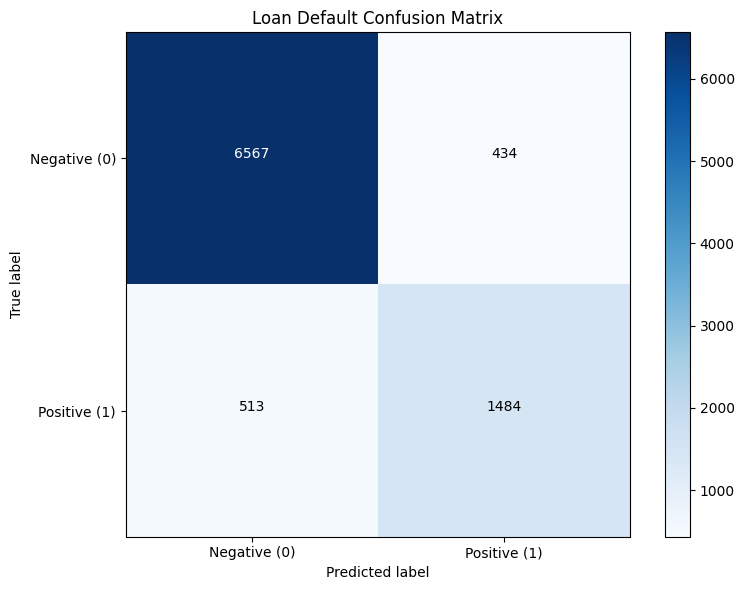

In [8]:
metrics = reg.get_metrics(X_test_scaled, y_test_np)
print("Loan Prediction Metrics:")
for k, v in metrics.items():
    if k != "Confusion Matrix":
        print(f"  {k}: {v:.4f}")

print("\nDisplaying Confusion Matrix...")
plot_confusion_matrix(y_test_np, reg.predict_classes(X_test_scaled), title='Loan Default Confusion Matrix')
